In [1]:
import pandas as pd
import numpy as np
import string
import re
import nltk

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

import matplotlib.pyplot as plt

nltk_stopwords = stopwords.words('english')

In [2]:
train_df = pd.read_csv("Project/data/train.txt", sep=";", names=["text", "label"])
val_df = pd.read_csv("Project/data/val.txt", sep=";", names=["text", "label"])
test_df = pd.read_csv("Project/data/test.txt", sep=";", names=["text", "label"])

In [3]:
def clean_text(input_text):
    output_text = str(input_text).translate(str.maketrans('', '', string.punctuation))
    output_text = output_text.lower()
    output_text = re.sub(r'\d+', '', output_text)
    return output_text

def lemm_text(input_text):
    lemmatizer = WordNetLemmatizer()
    words = word_tokenize(input_text)
    words = [word for word in words if word.lower() not in nltk_stopwords]
    lemmatized_words = [lemmatizer.lemmatize(word) for word in words]
    lemma_output = ' '.join(lemmatized_words)
    return lemma_output

def process_with_lemm(input_text):
    output_text = clean_text(input_text)
    output_text = lemm_text(output_text)
    return output_text

In [ ]:
train_cleaned = train_df.copy()
val_cleaned = val_df.copy()
test_cleaned = test_df.copy()

train_cleaned['text'] = train_cleaned['text'].apply(process_with_lemm)
val_cleaned['text'] = val_cleaned['text'].apply(process_with_lemm)
test_cleaned['text'] = test_cleaned['text'].apply(process_with_lemm)

train_cleaned.head()

,text,label
0,didnt feel humiliated,sadness
1,go feeling hopeless damned hopeful around some...,sadness
2,im grabbing minute post feel greedy wrong,anger
3,ever feeling nostalgic fireplace know still pr...,love
4,feeling grouchy,anger


In [ ]:
# IMPORTANT:
# Fit the TF-IDF vectorizer only on training data.
# Validation and test data should only use transform.

tfidf_vectorizer = TfidfVectorizer(max_features=5000)

X_train_temp = tfidf_vectorizer.fit_transform(train_cleaned['text'])
X_val_temp = tfidf_vectorizer.transform(val_cleaned['text'])
X_test_temp = tfidf_vectorizer.transform(test_cleaned['text'])

In [6]:
# Make sure all labels use the same order

emotion_order = sorted(train_cleaned['label'].unique())
print(emotion_order)

y_train_temp = pd.get_dummies(train_cleaned['label']).reindex(columns=emotion_order)
y_val_temp = pd.get_dummies(val_cleaned['label']).reindex(columns=emotion_order)
y_test_temp = pd.get_dummies(test_cleaned['label']).reindex(columns=emotion_order)

['anger', 'fear', 'joy', 'love', 'sadness', 'surprise']


In [7]:
X_train = X_train_temp.toarray()
X_val = X_val_temp.toarray()
X_test = X_test_temp.toarray()

y_train = y_train_temp.values
y_val = y_val_temp.values
y_test = y_test_temp.values

print(X_train.shape)
print(y_train.shape)

(16000, 5000)
(16000, 6)


In [8]:
model = Sequential()
model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
model.add(Dense(y_train.shape[1], activation='softmax'))

model.summary()

c:\Users\jqjur\miniconda3\envs\NLPE\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │       320,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320,454 (1.22 MB)

 Trainable params: 320,454 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
num_epochs = 10

history = model.fit(
    X_train[:3500],
    y_train[:3500],
    epochs=num_epochs,
    validation_data=(X_val, y_val)
)

Epoch 1/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4246 - loss: 1.6481 - val_accuracy: 0.5290 - val_loss: 1.4995
Epoch 2/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5983 - loss: 1.3194 - val_accuracy: 0.5855 - val_loss: 1.2501
Epoch 3/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7363 - loss: 0.9210 - val_accuracy: 0.6880 - val_loss: 0.9799
Epoch 4/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8871 - loss: 0.5665 - val_accuracy: 0.7620 - val_loss: 0.7869
Epoch 5/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9611 - loss: 0.3383 - val_accuracy: 0.7870 - val_loss: 0.6749
Epoch 6/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9854 - loss: 0.2094 - val_accuracy: 0.8015 - val_loss: 0.6084
Epoch 7/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9929 - loss: 0.1376 - val_accuracy: 0.8030 - val_loss: 0.5749
Epoch 8/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9951 - loss: 0.0965 - val_accuracy: 0.

In [11]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Accuracy: {accuracy}')

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8145 - loss: 0.5429
Accuracy: 0.8144999742507935


In [12]:
preds = model.predict(X_test)

predictions_cm = [np.argmax(each) for each in preds]
y_test_cm = [np.argmax(each) for each in y_test]

cm = confusion_matrix(y_test_cm, predictions_cm)
cm

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


array([[199,   7,  35,   5,  29,   0],
       [ 12, 147,  23,   0,  34,   8],
       [  5,  10, 639,  18,  20,   3],
       [  6,   1,  43,  98,  11,   0],
       [ 13,   6,  43,   3, 516,   0],
       [  4,  10,  16,   1,   5,  30]])

In [13]:
df_cm = pd.DataFrame(
    cm,
    index=emotion_order,
    columns=emotion_order
)

df_cm

,anger,fear,joy,love,sadness,surprise
anger,199,7,35,5,29,0
fear,12,147,23,0,34,8
joy,5,10,639,18,20,3
love,6,1,43,98,11,0
sadness,13,6,43,3,516,0
surprise,4,10,16,1,5,30


In [14]:
print(classification_report(
    y_test_cm,
    predictions_cm,
    target_names=emotion_order
))

              precision    recall  f1-score   support

       anger       0.83      0.72      0.77       275
        fear       0.81      0.66      0.73       224
         joy       0.80      0.92      0.86       695
        love       0.78      0.62      0.69       159
     sadness       0.84      0.89      0.86       581
    surprise       0.73      0.45      0.56        66

    accuracy                           0.81      2000
   macro avg       0.80      0.71      0.74      2000
weighted avg       0.81      0.81      0.81      2000



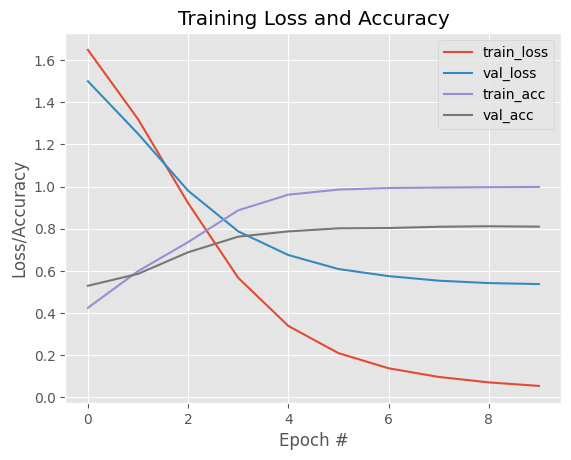

In [15]:
def plot_graphs(H):
  plt.style.use("ggplot")
  plt.figure()
  plt.plot(np.arange(0, num_epochs), H.history["loss"], label="train_loss")
  plt.plot(np.arange(0, num_epochs), H.history["val_loss"], label="val_loss")
  plt.plot(np.arange(0, num_epochs), H.history["accuracy"], label="train_acc")
  plt.plot(np.arange(0, num_epochs), H.history["val_accuracy"], label="val_acc")
  plt.title("Training Loss and Accuracy")
  plt.xlabel("Epoch #")
  plt.ylabel("Loss/Accuracy")
  plt.legend()
  plt.show()

plot_graphs(history)

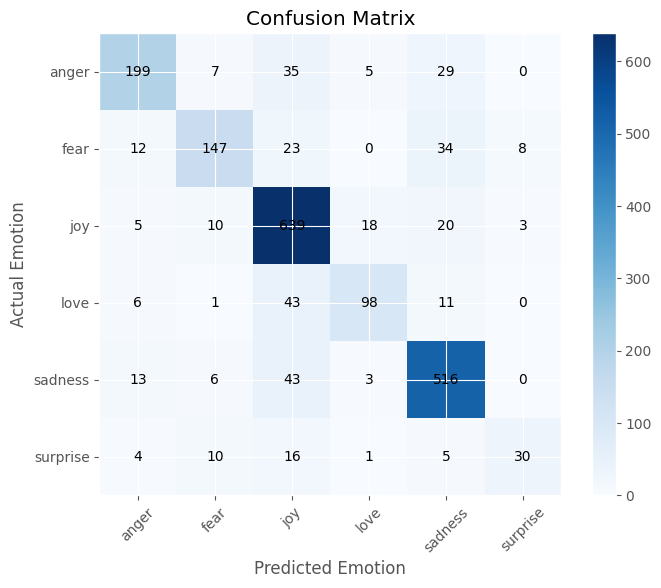

In [16]:
# Confusion matrix using only matplotlib

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(emotion_order))
plt.xticks(tick_marks, emotion_order, rotation=45)
plt.yticks(tick_marks, emotion_order)

plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")

for i in range(len(cm)):
    for j in range(len(cm[0])):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

In [17]:
def predict_emotion(sentence):
    cleaned_sentence = process_with_lemm(sentence)
    encoded_sentence = tfidf_vectorizer.transform([cleaned_sentence]).toarray()
    
    prediction = model.predict(encoded_sentence)
    predicted_index = np.argmax(prediction)
    predicted_emotion = emotion_order[predicted_index]
    
    print("Input text:", sentence)
    print("Predicted emotion:", predicted_emotion)

In [18]:
predict_emotion("I am so incredibly angry right now!")
predict_emotion("I feel very happy today!")
predict_emotion("I am scared about what will happen next.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Input text: I am so incredibly angry right now!
Predicted emotion: anger
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Input text: I feel very happy today!
Predicted emotion: joy
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Input text: I am scared about what will happen next.
Predicted emotion: fear


# Additional Imports For Part B

### Did not remove stopwords for LSTM Model

In [19]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [20]:
def lemm_text(input_text):
    lemmatizer = WordNetLemmatizer()

    words = word_tokenize(input_text)

    # NO STOPWORD REMOVAL
    lemmatized_words = [lemmatizer.lemmatize(word) for word in words]

    lemma_output = ' '.join(lemmatized_words)

    return lemma_output

## Tokenization

In [21]:
MAX_WORDS = 20000
MAX_LENGTH = 100

# Tokenizer
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")

# ONLY FIT ON TRAINING DATA
tokenizer.fit_on_texts(train_cleaned['text'])

# Convert text into sequences
X_train_seq = tokenizer.texts_to_sequences(train_cleaned['text'])
X_val_seq = tokenizer.texts_to_sequences(val_cleaned['text'])
X_test_seq = tokenizer.texts_to_sequences(test_cleaned['text'])

# Padding
X_train = pad_sequences(X_train_seq, maxlen=MAX_LENGTH, padding='post')
X_val = pad_sequences(X_val_seq, maxlen=MAX_LENGTH, padding='post')
X_test = pad_sequences(X_test_seq, maxlen=MAX_LENGTH, padding='post')

## Labels

In [22]:
emotion_order = sorted(train_cleaned['label'].unique())

y_train_temp = pd.get_dummies(train_cleaned['label']).reindex(columns=emotion_order)
y_val_temp = pd.get_dummies(val_cleaned['label']).reindex(columns=emotion_order)
y_test_temp = pd.get_dummies(test_cleaned['label']).reindex(columns=emotion_order)

y_train = y_train_temp.values
y_val = y_val_temp.values
y_test = y_test_temp.values

## Loading of my GloVe Embeddings

In [23]:
EMBEDDING_DIM = 100

embeddings_index = {}

with open('glove.6B.100d.txt', encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefficients = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefficients

print('Loaded %s word vectors.' % len(embeddings_index))

Loaded 400001 word vectors.


## Building my Embedding Matrix

In [24]:
word_index = tokenizer.word_index

embedding_matrix = np.zeros((MAX_WORDS, EMBEDDING_DIM))

for word, i in word_index.items():
    if i < MAX_WORDS:
        embedding_vector = embeddings_index.get(word)

        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

## Building my BiLSTM Model

In [25]:
model = Sequential()

model.add(
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LENGTH,
        trainable=False
    )
)

model.add(Bidirectional(LSTM(64, return_sequences=False)))

model.add(Dropout(0.5))

model.add(Dense(64, activation='relu'))

model.add(Dense(len(emotion_order), activation='softmax'))

model.summary()

c:\Users\jqjur\miniconda3\envs\NLPE\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,000,000 (7.63 MB)

## Compile my Model

In [26]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Implement early stopping

In [27]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

## Training of my model

In [28]:
num_epochs = 10

history = model.fit(
    X_train,
    y_train,
    epochs=num_epochs,
    validation_data=(X_val, y_val),
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.5166 - loss: 1.2929 - val_accuracy: 0.6560 - val_loss: 0.9365
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.7009 - loss: 0.8295 - val_accuracy: 0.7790 - val_loss: 0.5957
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.7942 - loss: 0.5784 - val_accuracy: 0.8375 - val_loss: 0.4590
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.8453 - loss: 0.4390 - val_accuracy: 0.8670 - val_loss: 0.3683
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.8737 - loss: 0.3548 - val_accuracy: 0.8830 - val_loss: 0.3175
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.8923 - loss: 0.2969 - val_accuracy: 0.8885 - val_loss: 0.3092
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.9056 - loss: 0.2605 - val_accuracy: 0.9000 - val_loss: 0.2777
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9191 - loss: 0.2218 - val_acc

## Evaluation of my model

In [29]:
loss, accuracy = model.evaluate(X_test, y_test)

print(f'Accuracy: {accuracy}')

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9080 - loss: 0.2472
Accuracy: 0.9079999923706055


## Predictions and confusion matrix

In [30]:
preds = model.predict(X_test)

predictions_cm = [np.argmax(each) for each in preds]
y_test_cm = [np.argmax(each) for each in y_test]

cm = confusion_matrix(y_test_cm, predictions_cm)

print(classification_report(
    y_test_cm,
    predictions_cm,
    target_names=emotion_order
))

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
              precision    recall  f1-score   support

       anger       0.94      0.89      0.91       275
        fear       0.85      0.95      0.90       224
         joy       0.93      0.92      0.92       695
        love       0.77      0.83      0.80       159
     sadness       0.94      0.94      0.94       581
    surprise       0.82      0.64      0.72        66

    accuracy                           0.91      2000
   macro avg       0.88      0.86      0.87      2000
weighted avg       0.91      0.91      0.91      2000



# Graphs

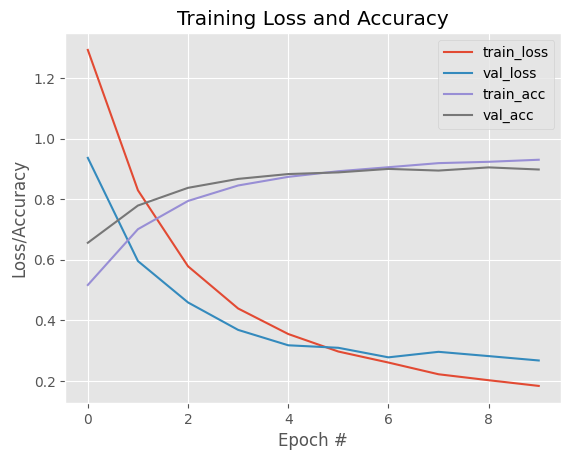

In [31]:
plot_graphs(history)

## Live prediction function

In [32]:
def predict_emotion(text):

    cleaned = process_with_lemm(text)

    sequence = tokenizer.texts_to_sequences([cleaned])

    padded = pad_sequences(sequence, maxlen=MAX_LENGTH, padding='post')

    prediction = model.predict(padded)

    predicted_label = emotion_order[np.argmax(prediction)]

    print(f'Predicted Emotion: {predicted_label}')

In [41]:
predict_emotion("i am so happy")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Predicted Emotion: joy
